Base Parameter values:
epsilon = 0.0
M = 1.0
g = 3.0
a = 3.4
L = R for paramater variations

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import odeint
from scipy.signal import find_peaks

In [22]:
def dELdt(EL, ER, HL, L_input, params):
    M = params['M']
    a = params['a']
    g = params['g']
    epsilon = params['epsilon']
    tau = params["tau"]
    x = L_input - a*ER + epsilon*EL - g*HL
    return (-EL + M*x) /tau

def dERdt(ER, EL, HR, R_input, params):
    M = params['M']
    a = params['a']
    g = params['g']
    epsilon = params['epsilon']
    tau = params["tau"]
    x = R_input - a*EL + epsilon*ER - g*HR
    return (-ER + M*x) / tau

def dHLdt(HL, EL, params):
    tau_h = params['tau_h']
    return (-HL + EL) / tau_h

def dHRdt(HR, ER, params):
    tau_h = params['tau_h']
    return (-HR + ER) / tau_h

In [23]:
def dXdt(X, t, L_input=1.0, R_input=0.86):
    tau = 15.0
    tau_H = 996.0
    M = 1.0
    a = 3.4
    epsilon = 0.0
    g = 3.0

    EL, ER, HL, HR = X

    dEL = (-EL + M * np.maximum(L_input - a * ER + epsilon * EL - g * HL, 0)) / tau
    dER = (-ER + M * np.maximum(R_input - a * EL + epsilon * ER - g * HR, 0)) / tau
    dHL = (-HL + EL) / tau_H
    dHR = (-HR + ER) / tau_H

    return [dEL, dER, dHL, dHR]

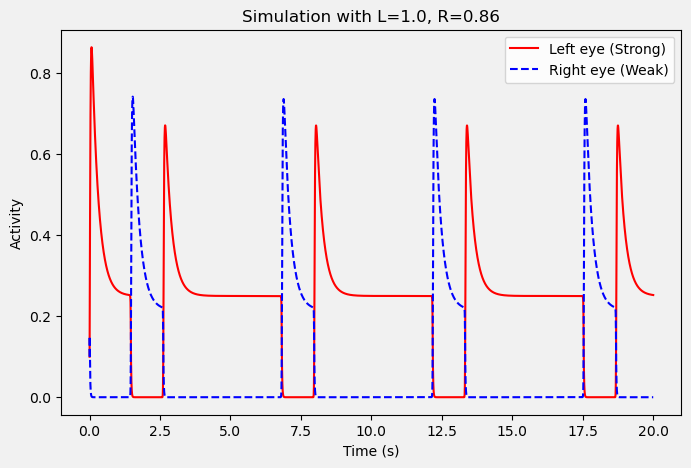

In [24]:
# figure 2
X0 = [0.1, 0.1, 0.0, 0.0]
t = np.linspace(0, 20000, 5001)

X = odeint(dXdt, X0, t)
EL, ER, HL, HR = X.T

fig = plt.figure(figsize=(8, 5))
fig.patch.set_facecolor('#f1f1f1')
plt.gca().set_facecolor('#f1f1f1')
plt.plot(t/1000, EL, 'r-', label='Left eye (Strong)') # Divided by 1000 for seconds
plt.plot(t/1000, ER, 'b--', label='Right eye (Weak)')
plt.title(f"Simulation with L={1.0}, R={0.86}")
plt.xlabel('Time (s)')
plt.ylabel('Activity')
plt.legend()
plt.show()

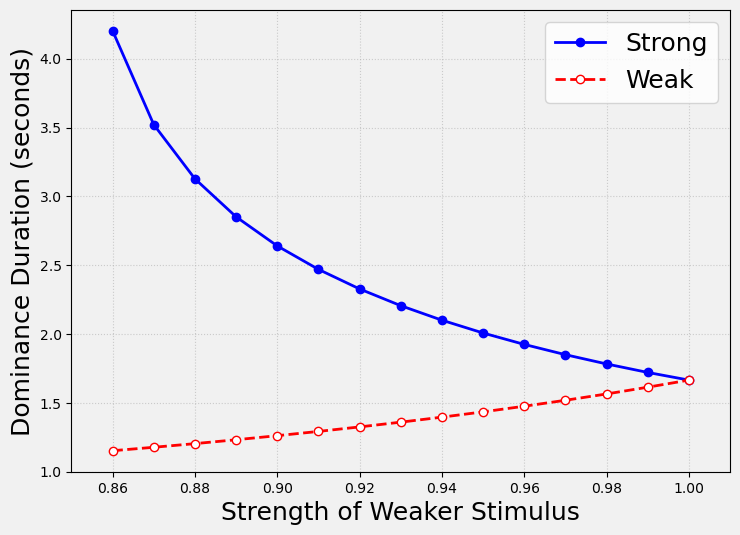

In [25]:
# figure 3
R_strengths = np.linspace(0.86, 1.0, 15) 
L_strength = 1.0

avg_durations_strong = []
avg_durations_weak = []

t = np.linspace(0, 100000, 100000)
X0 = [0.11, 0.1, 0.0, 0.0]

for R_val in R_strengths:
    X = odeint(dXdt, X0, t, args=(L_strength, R_val))
    X0_new = X[-1,:] 
    X = odeint(dXdt, X0_new, t, args=(L_strength, R_val))
    EL = X[:, 0]
    ER = X[:, 1]
    peaks_L, _ = find_peaks(EL, height=0.1)
    peaks_R, _ = find_peaks(ER, height=0.1)

    events = [(i, 'L') for i in peaks_L] + [(i, 'R') for i in peaks_R]
    events.sort(key=lambda x: x[0]) # Sort by time
    
    durations_L = []
    durations_R = []
    
    #find alternating L- R - L patterns
    for k in range(len(events) - 1):
        idx_curr, eye_curr = events[k]
        idx_next, eye_next = events[k+1]
        dt_seconds = (t[idx_next] - t[idx_curr]) / 1000.0
        
        if eye_curr == 'L' and eye_next == 'R':
            # Time from L peak to R peak
            durations_L.append(dt_seconds)
        elif eye_curr == 'R' and eye_next == 'L':
            # Time from R peak to L peak
            durations_R.append(dt_seconds)
            
    if durations_L:
        avg_durations_strong.append(np.mean(durations_L))
    else:
        avg_durations_strong.append(np.nan)
        
    if durations_R:
        avg_durations_weak.append(np.mean(durations_R))
    else:
        avg_durations_weak.append(np.nan)


fig = plt.figure(figsize=(8.5, 6))
fig.patch.set_facecolor('#f1f1f1')
plt.gca().set_facecolor('#f1f1f1')
plt.plot(R_strengths, avg_durations_strong, 'o-', color='blue', label='Strong', linewidth=2)
plt.plot(R_strengths, avg_durations_weak, 'o--', color='red', label='Weak', mfc='white', linewidth=2)
plt.xlabel('Strength of Weaker Stimulus', fontsize=18)
plt.ylabel('Dominance Duration (seconds)', fontsize=18)
plt.legend(prop={'size': 18,})
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0.85, 1.01)
plt.show()

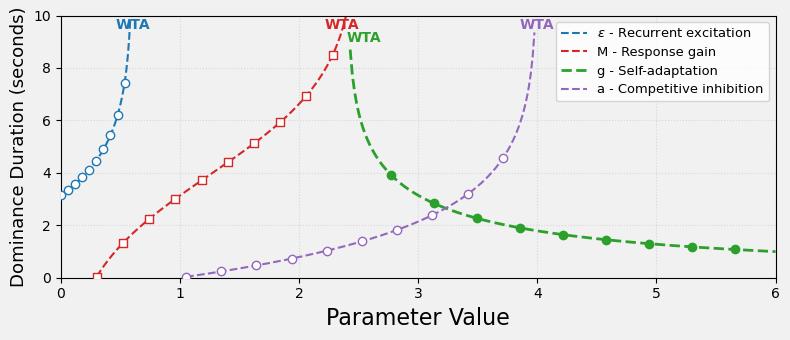

In [26]:
#Fig 5 

def theoretical_duration(params, L=1.0, R=1.0):
    tau_H = 1.95 
    M = params['M']
    g = params['g']
    eps = params['epsilon']
    a = params['a']
    

    # eq 8
    denom = (1/M) + g - eps - (a * (L/R))
    
    with np.errstate(divide='ignore', invalid='ignore'):
        arg = g / denom
        T = tau_H * np.log(arg)
        T = np.where((denom <= 0) | (arg <= 1.0), np.nan, T)
        
    return T

base = {'M': 1.0, 'g': 3.0, 'epsilon': 0.0, 'a': 3.4}


#e
eps_limit = (1/base['M']) + base['g'] - base['a']
eps_vals = np.linspace(0, eps_limit - 0.01, 200)
T_eps = theoretical_duration({'M': 1.0, 'g': 3.0, 'epsilon': eps_vals, 'a': 3.4})

# M
M_limit = 1.0 / (base['a'] - base['g'] + base['epsilon'])
M_vals = np.linspace(0.3, M_limit - 0.01, 200)
T_M = theoretical_duration({'M': M_vals, 'g': 3.0, 'epsilon': 0.0, 'a': 3.4})

# g
g_limit = base['a'] + base['epsilon'] - (1/base['M'])
g_vals = np.linspace(g_limit + 0.01, 6.0, 200)
T_g = theoretical_duration({'M': 1.0, 'g': g_vals, 'epsilon': 0.0, 'a': 3.4})

#a
a_limit = (1/base['M']) + base['g'] - base['epsilon']
a_vals = np.linspace(1.05, a_limit - 0.01, 200)
T_a = theoretical_duration({'M': 1.0, 'g': 3.0, 'epsilon': 0.0, 'a': a_vals})


def ten_s_plot(T): 
    return np.where(T > 10, np.nan, T) # cuts after 10 seconds

fig = plt.figure(figsize=(8, 3.5))
fig.patch.set_facecolor('#f1f1f1')
plt.gca().set_facecolor('#f1f1f1')

c_eps = 'tab:blue'
c_M = 'tab:red'
c_g = 'tab:green'
c_a = 'tab:purple'

plt.plot(eps_vals, ten_s_plot(T_eps), '--', color=c_eps, label=r'$\epsilon$ - Recurrent excitation')
plt.scatter(eps_vals[::20], ten_s_plot(T_eps)[::20], color='white', edgecolors=c_eps, zorder=3)
plt.text(eps_limit, 9.5, "WTA", color=c_eps, fontweight='bold', ha='center')

plt.plot(M_vals, ten_s_plot(T_M), '--', color=c_M, label='M - Response gain')
plt.scatter(M_vals[::20], ten_s_plot(T_M)[::20], marker='s', color='white', edgecolors=c_M, zorder=3)
plt.text(M_limit, 9.5, "WTA", color=c_M, fontweight='bold', ha='right')

plt.plot(g_vals, ten_s_plot(T_g), '--', color=c_g, linewidth=2, label='g - Self-adaptation')
plt.scatter(g_vals[::20], ten_s_plot(T_g)[::20], color=c_g, edgecolors=c_g, zorder=3)
plt.text(g_limit, 9.0, "WTA", color=c_g, fontweight='bold', ha='left')

plt.plot(a_vals, ten_s_plot(T_a), '--', color=c_a, label='a - Competitive inhibition')
plt.scatter(a_vals[::20], ten_s_plot(T_a)[::20], color='white', edgecolors=c_a, zorder=3)
plt.text(a_limit, 9.5, "WTA", color=c_a, fontweight='bold', ha='center')

plt.xlabel('Parameter Value', fontsize=16)
plt.ylabel('Dominance Duration (seconds)', fontsize=13)
plt.ylim(0, 10)
plt.xlim(0, 6)
plt.legend(prop={'size': 9.4})
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

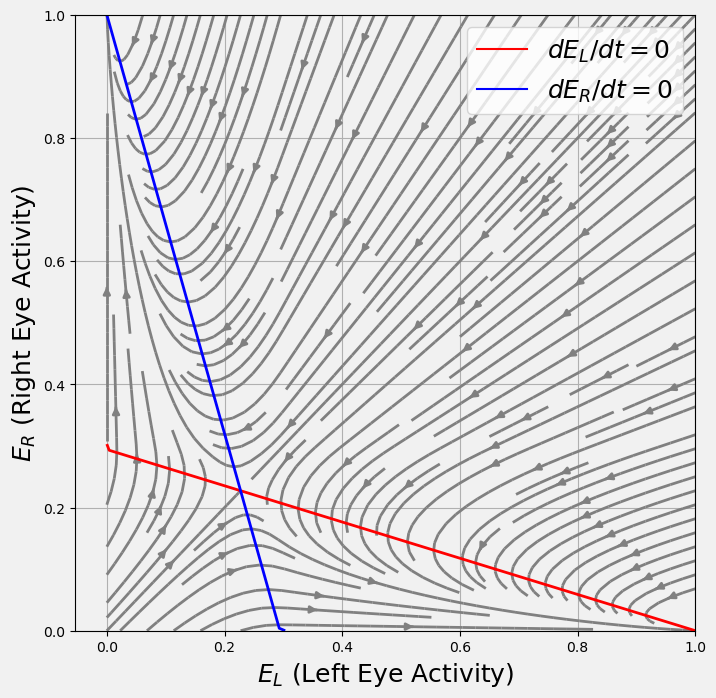

In [27]:
# phase plane diagram

M = 1.0
a = 3.4
epsilon = 0.0
g = 3.0
tau = 15.0
L = 1.0
R = 1.0

# Jacobian Calculations
J_11 = (-1 + M * epsilon) / tau
J_12 = (-M * a) / tau
J_21 = (-M * a) / tau
J_22 = (-1 + M * epsilon) / tau
jacobian = np.array([[J_11, J_12],
                     [J_21, J_22]])
eigenvalues = np.linalg.eigvals(jacobian)
max_eigenvalue = np.max(np.real(eigenvalues))

HL_fixed = 0.0
HR_fixed = 0.0

E_range = np.linspace(0, 1.0, 100)
E_grid_L, E_grid_R = np.meshgrid(E_range, E_range)

# derivatives for the vector field
dEL = (-E_grid_L + M * np.maximum(L - a * E_grid_R + epsilon * E_grid_L - g * HL_fixed, 0)) / tau
dER = (-E_grid_R + M * np.maximum(R - a * E_grid_L + epsilon * E_grid_R - g * HR_fixed, 0)) / tau

fig = plt.figure(figsize=(8, 8))
fig.patch.set_facecolor('#f1f1f1')
plt.gca().set_facecolor('#f1f1f1')
plt.xlabel("$E_L$ (Left Eye Activity)", fontsize=18)
plt.ylabel("$E_R$ (Right Eye Activity)", fontsize=18)
plt.streamplot(E_range, E_range, dEL, dER, color='gray', linewidth=2, density=1.5)
plt.contour(E_grid_L, E_grid_R, dEL, levels=[0], colors='red', linewidths=2)
plt.contour(E_grid_L, E_grid_R, dER, levels=[0], colors='blue', linewidths=2)
red_line = mlines.Line2D([], [], color='red', label='$dE_L/dt = 0$')
blue_line = mlines.Line2D([], [], color='blue', label='$dE_R/dt = 0$')
plt.legend(handles=[red_line, blue_line], loc='upper right', prop={'size': 18, 'weight': 'bold'})
plt.grid(True)
plt.show()

In [28]:
def calculate_4d_eigenvalues(params):
    M = params['M']
    a = params['a']
    g = params['g']
    eps = params['epsilon']
    tau = params['tau']
    tau_h = params['tau_h']
    
    # Jacobian Matrix
    r1 = [(-1 + M*eps)/tau, (-M*a)/tau, (-M*g)/tau, 0]
    r2 = [(-M*a)/tau, (-1 + M*eps)/tau, 0, (-M*g)/tau]
    r3 = [1/tau_h, 0, -1/tau_h, 0]
    r4 = [0, 1/tau_h, 0, -1/tau_h]
    
    J = np.array([r1, r2, r3, r4])
    
    # Calculate Eigenvalues
    eigenvalues = np.linalg.eigvals(J)
    
    print(f"\nResults for Inhibition (a) = {a}:")
    for i, lam in enumerate(eigenvalues):
        real_part = lam.real
        imag_part = lam.imag
        
        print(f"λ{i+1}: {real_part:+.5f} {imag_part:+.5f}i")


# Strong Rivalry
params_standard = {
    'M': 1, 'a': 3.4, 'g': 3.0, 'epsilon': 0.0,
    'tau': 15.0, 'tau_h': 996.0
}

# limit cycle - hopf
params_low_inhibition = params_standard.copy()
params_low_inhibition['a'] = 1.05 

calculate_4d_eigenvalues(params_standard)
calculate_4d_eigenvalues(params_low_inhibition)


Results for Inhibition (a) = 3.4:
λ1: -0.29264 +0.00000i
λ2: +0.15874 +0.00000i
λ3: +0.00025 +0.00000i
λ4: -0.00169 +0.00000i

Results for Inhibition (a) = 1.05:
λ1: -0.13517 +0.00000i
λ2: +0.00116 +0.01400i
λ3: +0.00116 -0.01400i
λ4: -0.00250 +0.00000i


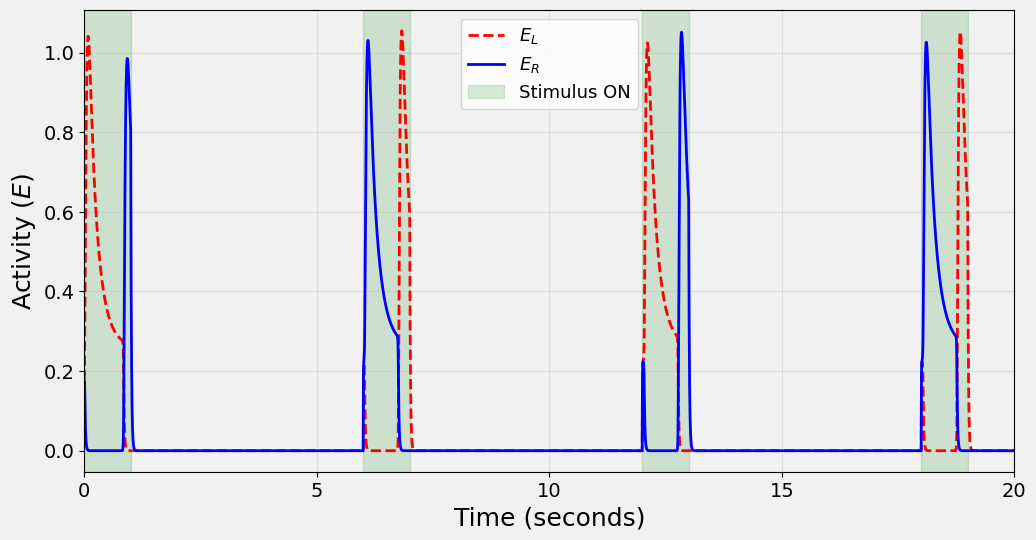

In [29]:


tau = 15.0 
tau_H = 996.0
tau_F = 20.0 
tau_A = 500.0 
M = 1.0
a = 3.4
g = 3.0
epsilon = 0.2

def sigmoid_fac(x):
    """Bistable sigmoid function for facilitation (Equation 11)"""
    return 1.25 * (x**2) / (0.25 + x**2)

def rivalry_memory_model(y, t, L_in, R_in):
    EL, ER, HL, HR, FL, FR, AL, AR = y
    
    # Recurrent excitation modulated by facilitation F
    recL = epsilon * FL * EL
    recR = epsilon * FR * ER
    
    # Eq 2 modified
    dEL = (-EL + M * np.maximum(L_in - a * ER + recL - g * HL, 0)) / tau
    dER = (-ER + M * np.maximum(R_in - a * EL + recR - g * HR, 0)) / tau
    
    # Eq 2
    dHL = (-HL + EL) / tau_H
    dHR = (-HR + ER) / tau_H
    
    # eq 11
    dFL = (-FL + sigmoid_fac(FL + EL) - AL) / tau_F
    dFR = (-FR + sigmoid_fac(FR + ER) - AR) / tau_F
    dAL = (-AL + EL) / tau_A
    dAR = (-AR + ER) / tau_A
    
    return [dEL, dER, dHL, dHR, dFL, dFR, dAL, dAR]

# Simulation parameters
pulse_dur = 1000.0 #stimulus on
blank_dur = 5000.0 #stimulus off
t_stop = 20000.0 
dt = 2.0            

t_eval = np.arange(0, t_stop, dt)

y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
results = []
curr_y = y0

for i, t in enumerate(t_eval):
    cycle_time = t % (pulse_dur + blank_dur)
    if cycle_time < pulse_dur:
        # Stimulus ON
        L_in, R_in = (1.0, 0.95) if t < pulse_dur else (1.0, 1.0)
    else:
        # Stimulus OFF
        L_in, R_in = 0.0, 0.0
        
    res = odeint(rivalry_memory_model, curr_y, [t, t+dt], args=(L_in, R_in))
    curr_y = res[-1]
    results.append(curr_y)

results = np.array(results)


fig = plt.figure(figsize=(12, 6))
fig.patch.set_facecolor('#f1f1f1')
plt.gca().set_facecolor('#f1f1f1')
plt.plot(t_eval / 1000, results[:, 0], label='$E_L$', color='red', linestyle="--", linewidth=2)
plt.plot(t_eval / 1000, results[:, 1], label='$E_R$', color='blue', linewidth=2)
# Stimulus overlay
cycle_total = (pulse_dur + blank_dur) / 1000  # 6 seconds
for i in range(int(20 / cycle_total) + 1):
    start = i * cycle_total
    if start < 20:
        end = min(start + (pulse_dur / 1000), 20)
        plt.axvspan(start, end, color='green', alpha=0.15, label='Stimulus ON' if i==0 else "")

plt.xticks(np.arange(0, 21, 5)) 
plt.xlim(0, 20)
plt.xlabel('Time (seconds)', fontsize=18)
plt.ylabel('Activity ($E$)', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14) 
plt.legend(prop={'size': 13})
plt.grid(True, alpha=0.3)
plt.show()